# Configuration


In [1]:
# Install required libraries
!pip install -q transformers datasets evaluate accelerate scikit-learn

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from datasets import load_dataset
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer
)
import evaluate

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Runtime is utilizing device: {device.upper()}")
if device == "cpu":
    print("WARNING: GPU is not detected. Go to Settings -> Accelerator -> GPU T4x2 or P100.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
c

# EDA

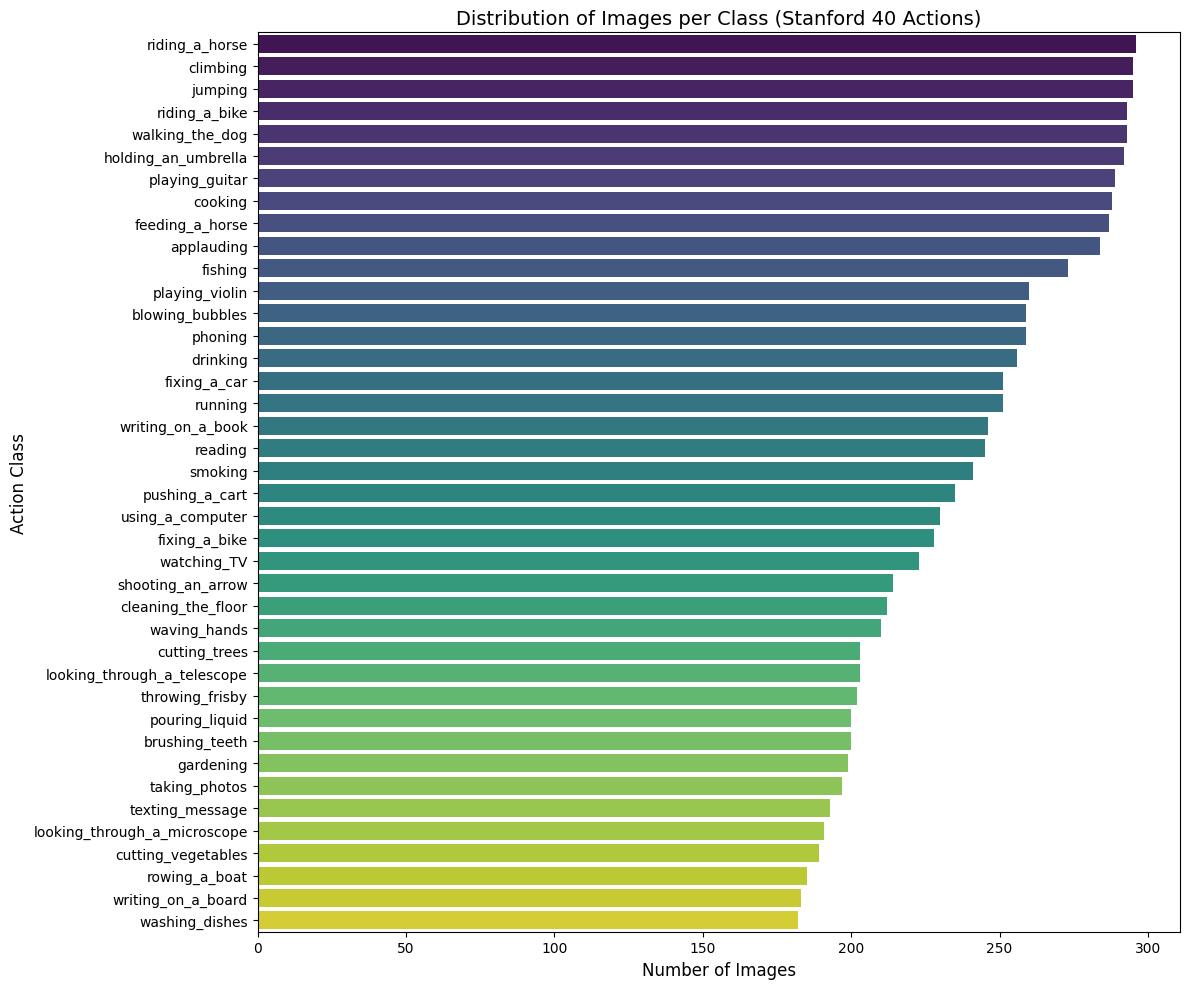

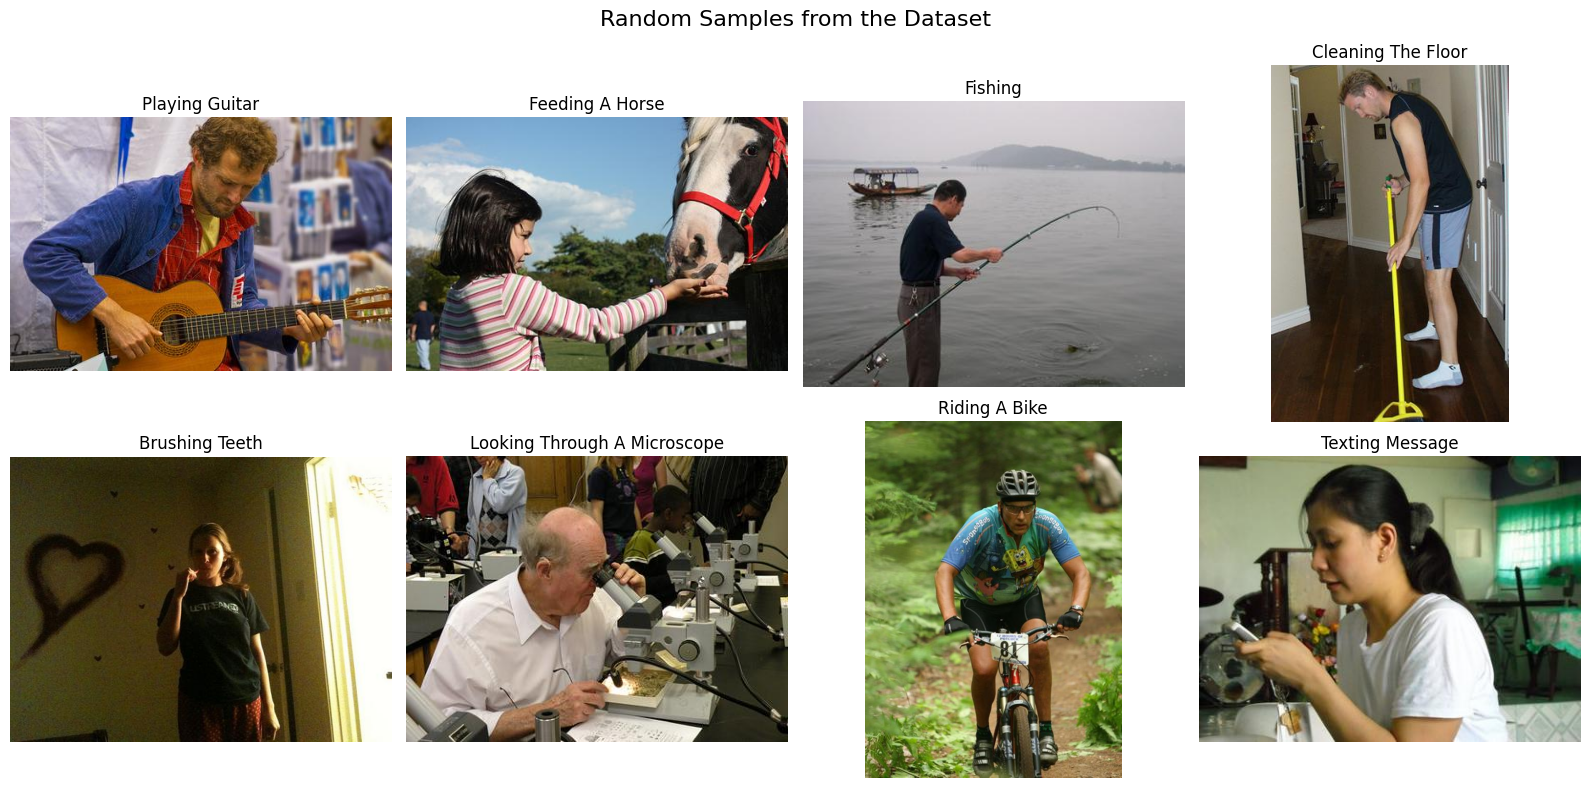

In [2]:
DATASET_PATH = "/kaggle/input/datasets/abdullaalriad/stanford-40-full/train_FUll"

# 1. Class Distribution
classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
class_counts = {c: len(os.listdir(os.path.join(DATASET_PATH, c))) for c in classes}
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count']).sort_values('Count', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Class', data=df_counts, palette='viridis')
plt.title('Distribution of Images per Class (Stanford 40 Actions)', fontsize=14)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Action Class', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Random Image Samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = random.sample(classes, 8)

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))
    
    ax = axes[i//4, i%4]
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=12)
    ax.axis('off')
    
plt.suptitle('Random Samples from the Dataset', fontsize=16)
plt.tight_layout()
plt.show()

# Preprocessing

In [3]:
# Load dataset directly from the folder structure
dataset = load_dataset("imagefolder", data_dir=DATASET_PATH, drop_labels=False)

# Split into 85% Train / 15% Validation
dataset = dataset['train'].train_test_split(test_size=0.15, seed=42)

# Extract mappings for the classifier head
labels = dataset['train'].features['label'].names
id2label = {str(i): label for i, label in enumerate(labels)}
label2id = {label: str(i) for i, label in enumerate(labels)}

# Initialize Image Processor (extracts mean/std for the specific ViT architecture)
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)

# Define torchvision transforms
from torchvision.transforms import Compose, Normalize, RandomResizedCrop, RandomHorizontalFlip, ToTensor, Resize, CenterCrop

normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

# Training transforms include data augmentation to prevent overfitting
train_transforms = Compose([
    RandomResizedCrop(processor.size["height"]),
    RandomHorizontalFlip(),
    ToTensor(),
    normalize
])

# Validation transforms only resize and crop
val_transforms = Compose([
    Resize(processor.size["height"]),
    CenterCrop(processor.size["height"]),
    ToTensor(),
    normalize
])

def preprocess_train(example_batch):
    example_batch["pixel_values"] = [train_transforms(img.convert("RGB")) for img in example_batch["image"]]
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [val_transforms(img.convert("RGB")) for img in example_batch["image"]]
    return example_batch

# Apply transformations on the fly
train_ds = dataset['train'].with_transform(preprocess_train)
val_ds = dataset['test'].with_transform(preprocess_val)

print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")

Resolving data files:   0%|          | 0/9532 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Training samples: 8102
Validation samples: 1430


# Model Init

In [4]:
# Load accuracy metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Initialize the model with the pre-trained weights and a new classification head
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # Required when changing the classification head size
)

# Custom data collator to format the batches correctly for PyTorch
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training execution

In [5]:
# Define training hyperparameters optimized for Kaggle
training_args = TrainingArguments(
    output_dir="/kaggle/working/vit-stanford-40-checkpoints",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32, # Safe for 16GB Kaggle GPUs (T4/P100)
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True, # Crucial for Kaggle GPU optimization
    report_to="none" # Prevents prompts for WandB login
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=processor, # <--- FIXED HERE
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

print("Starting training...")
train_results = trainer.train()

# Log final training metrics
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
print("Starting training...")
train_results = trainer.train()

# Log final training metrics
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,2.887910,0.730070
2,No log,2.286122,0.805594
3,No log,1.966787,0.827972
4,2.575458,1.810358,0.838462
5,2.575458,1.759768,0.839860


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** train metrics *****
  epoch                    =          5.0
  total_flos               = 2924604019GF
  train_loss               =       1.3946
  train_runtime            =   0:17:59.20
  train_samples_per_second =       37.537
  train_steps_per_second   =        0.588


# Evalutaion

In [6]:

eval_metrics = trainer.evaluate()
trainer.log_metrics("eval", eval_metrics)
trainer.save_metrics("eval", eval_metrics)


print("\n" + "="*50)
print(f"{'FINAL EVALUATION RESULTS':^50}")
print("="*50)
for key, value in eval_metrics.items():
    if isinstance(value, float):
        print(f"| {key:>25} | {value:15.4f} |")
    else:
        print(f"| {key:>25} | {str(value):>15} |")
print("="*50)


FINAL_MODEL_PATH = "/kaggle/working/vit-stanford-40-final"

trainer.save_model(FINAL_MODEL_PATH)
processor.save_pretrained(FINAL_MODEL_PATH)

print(f"\n Training Complete!")
print(f" Final Model weights, config, and processor saved to: {FINAL_MODEL_PATH}")
print("   -> You can now compress this folder or download the files directly from the Kaggle 'Output' pane.")

***** eval metrics *****
  epoch                   =        5.0
  eval_accuracy           =     0.8853
  eval_loss               =      1.046
  eval_runtime            = 0:00:16.60
  eval_samples_per_second =     86.124
  eval_steps_per_second   =      1.385

             FINAL EVALUATION RESULTS             
|                 eval_loss |          1.0460 |
|             eval_accuracy |          0.8853 |
|              eval_runtime |         16.6039 |
|   eval_samples_per_second |         86.1240 |
|     eval_steps_per_second |          1.3850 |
|                     epoch |          5.0000 |


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Training Complete!
 Final Model weights, config, and processor saved to: /kaggle/working/vit-stanford-40-final
   -> You can now compress this folder or download the files directly from the Kaggle 'Output' pane.
